In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(5)

N = 1000

# Випадкові точки у прямокутнику [0,4] × [0,3]
x = np.random.uniform(0, 4, N)
y = np.random.uniform(0, 3, N)

# Умова потрапляння в трикутник
inside = (x / 4 + y / 3 <= 1)

# Частка точок усередині
p = inside.mean()

# Площа прямокутника
rectangle_area = 4 * 3

# Оцінка площі трикутника
mc_area = p * rectangle_area

print("Кількість точок:", N)
print("Точок усередині:", inside.sum())
print("Частка всередині:", p)
print("Оцінка площі:", mc_area)

Кількість точок: 1000
Точок усередині: 481
Частка всередині: 0.481
Оцінка площі: 5.772


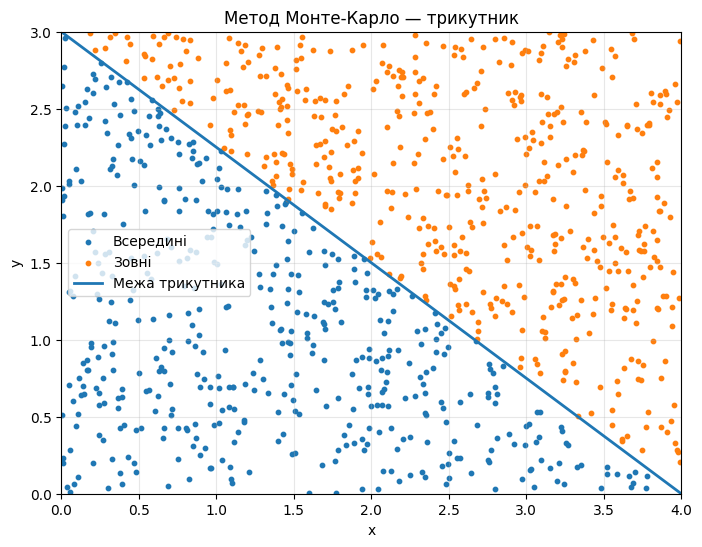

In [2]:
plt.figure(figsize=(8, 6))

plt.scatter(
    x[inside],
    y[inside],
    s=10,
    label="Всередині"
)

plt.scatter(
    x[~inside],
    y[~inside],
    s=10,
    label="Зовні"
)

plt.plot(
    [0, 4],
    [3, 0],
    linewidth=2,
    label="Межа трикутника"
)

plt.xlim(0, 4)
plt.ylim(0, 3)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Метод Монте-Карло — трикутник")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Для N = 1000 випадкових точок у прямокутнику
[0,4] × [0,3] у трикутник потрапила 481 точка.

Частка точок усередині:

481 / 1000 = 0.481.

Площа прямокутника-охоплення дорівнює:

4 × 3 = 12.

Тому оцінка площі трикутника методом Монте-Карло:

S ≈ 0.481 × 12 = 5.772.

Отримана оцінка близька до точного значення 6.

In [3]:
exact_area = 6

absolute_error = abs(mc_area - exact_area)

relative_error = (
    absolute_error / exact_area * 100
)

print("Оцінка Монте-Карло:", mc_area)
print("Точна площа:", exact_area)
print("Абсолютна похибка:", absolute_error)
print("Відносна похибка:", relative_error, "%")

Оцінка Монте-Карло: 5.772
Точна площа: 6
Абсолютна похибка: 0.22799999999999976
Відносна похибка: 3.799999999999996 %


Точна площа трикутника дорівнює 6.

Метод Монте-Карло при N = 1000 дав:

S ≈ 5.772.

Абсолютна похибка:

|5.772 - 6| = 0.228.

Відносна похибка:

0.228 / 6 × 100% = 3.8%.

Похибка 3.8% є відносно невеликою, особливо
враховуючи, що використано лише 1000 випадкових
точок.

Метод Монте-Карло має випадкову похибку, тому
результат не повинен точно дорівнювати 6.

Зі збільшенням кількості випробувань оцінка
в середньому повинна наближатися до точного значення.

In [4]:
N_values = [
    100,
    1000,
    10000,
    100000
]

results = []

for N in N_values:
    np.random.seed(5)

    x = np.random.uniform(0, 4, N)
    y = np.random.uniform(0, 3, N)

    inside = (x / 4 + y / 3 <= 1)

    estimate = inside.mean() * 12

    error = abs(
        estimate - exact_area
    )

    results.append({
        "N": N,
        "Оцінка площі": estimate,
        "Абсолютна похибка": error
    })

results_df = pd.DataFrame(results)

results_df

,N,Оцінка площі,Абсолютна похибка
0,100,5.52000,0.48000
1,1000,5.77200,0.22800
2,10000,5.84640,0.15360
3,100000,5.97036,0.02964


In [5]:
error_100 = results_df.loc[
    results_df["N"] == 100,
    "Абсолютна похибка"
].iloc[0]

error_10000 = results_df.loc[
    results_df["N"] == 10000,
    "Абсолютна похибка"
].iloc[0]

ratio = error_100 / error_10000

print(
    "Похибка зменшилась приблизно у",
    ratio,
    "раза"
)

Похибка зменшилась приблизно у 3.124999999999998 раза


При збільшенні кількості випробувань оцінка площі
в цілому наближається до точного значення 6.

Для N = 100:
S ≈ 5.52,
похибка ≈ 0.48.

Для N = 100000:
S ≈ 5.97036,
похибка ≈ 0.02964.

При переході від N = 100 до N = 10000 кількість
випробувань збільшилась у 100 разів.

Теоретично типовий масштаб випадкової похибки
Монте-Карло зменшується як 1/sqrt(N).

Тому збільшення N у 100 разів відповідає приблизно
10-кратному зменшенню стандартної похибки:

sqrt(100) = 10.

У конкретній реалізації абсолютна похибка зменшилась
з 0.48 до 0.1536, тобто приблизно у 3.13 раза,
а не рівно у 10 разів.

Це не суперечить теорії, оскільки абсолютна похибка
одного конкретного випадкового запуску може
коливатися. Закон 1/sqrt(N) описує типовий масштаб
похибки, а не гарантує точне зменшення похибки
у кожному окремому запуску.

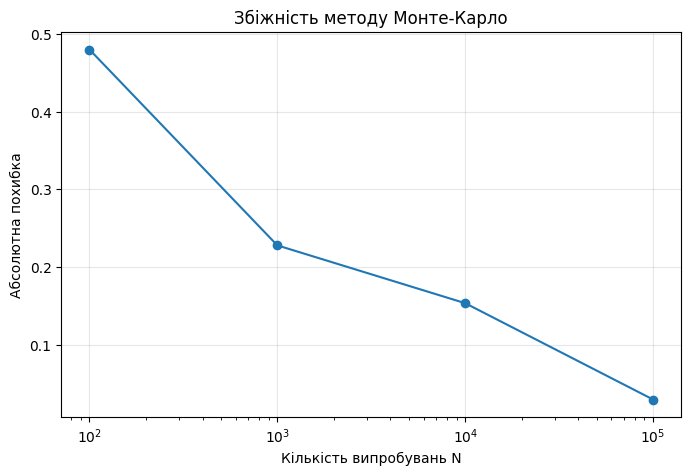

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results_df["N"],
    results_df["Абсолютна похибка"],
    marker="o"
)

ax.set_xscale("log")

ax.set_xlabel("Кількість випробувань N")
ax.set_ylabel("Абсолютна похибка")
ax.set_title("Збіжність методу Монте-Карло")

ax.grid(alpha=0.3)

plt.show()

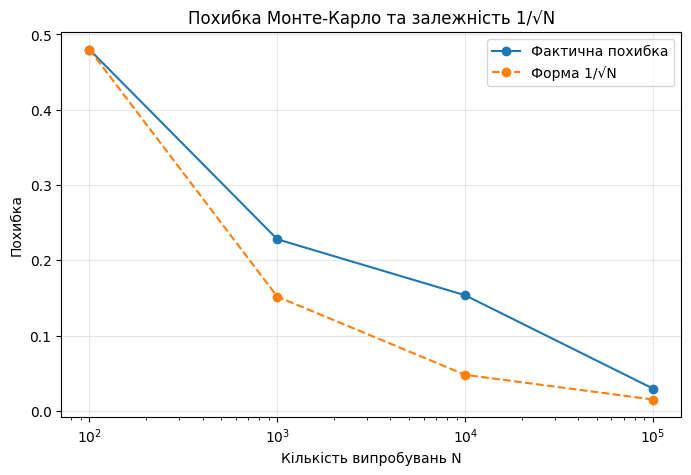

In [7]:
theory = 1 / np.sqrt(
    results_df["N"]
)

# Масштабуємо лише для зручного порівняння форми
theory_scaled = (
    theory
    / theory.iloc[0]
    * results_df["Абсолютна похибка"].iloc[0]
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    results_df["N"],
    results_df["Абсолютна похибка"],
    marker="o",
    label="Фактична похибка"
)

ax.plot(
    results_df["N"],
    theory_scaled,
    marker="o",
    linestyle="--",
    label="Форма 1/√N"
)

ax.set_xscale("log")

ax.set_xlabel("Кількість випробувань N")
ax.set_ylabel("Похибка")
ax.set_title("Похибка Монте-Карло та залежність 1/√N")

ax.legend()
ax.grid(alpha=0.3)

plt.show()

На графіку видно загальну тенденцію до зменшення
абсолютної похибки зі збільшенням N.

Для нашого запуску похибка зменшується:

0.48000;
0.22800;
0.15360;
0.02964.

Тобто в цих чотирьох точках вона спадає монотонно.

Водночас метод Монте-Карло є випадковим, тому в інших
реалізаціях похибка не зобов'язана зменшуватися
строго на кожному наступному значенні N.

Загальний масштаб похибки поводиться приблизно
відповідно до залежності 1/√N.

Тому для суттєвого збільшення точності потрібно
значно збільшувати кількість випробувань.

У моєму варіанті кожну випадкову точку можна
представити індикаторною випадковою величиною:

I = 1, якщо точка потрапила в трикутник;
I = 0, якщо точка не потрапила в трикутник.

Середнє значення цих індикаторів:

(I1 + I2 + ... + IN) / N

дорівнює частці випадкових точок, які потрапили
в трикутник.

Саме цю частку ми множимо на площу прямокутника 12
і отримуємо оцінку площі.


1. Закон великих чисел

Закон великих чисел гарантує, що при збільшенні N
вибіркове середнє індикаторів наближається до
їхнього математичного сподівання.

Математичне сподівання індикатора дорівнює
ймовірності потрапляння випадкової точки
в трикутник.

У нашому випадку:

P(точка в трикутнику) =
площа трикутника / площа прямокутника =
6 / 12 = 0.5.

Тому при великому N частка точок усередині
наближається до 0.5.

Після множення на площу прямокутника:

0.5 × 12 = 6.

Отже, саме закон великих чисел пояснює,
чому оцінка Монте-Карло наближається до
точної площі зі збільшенням N.


2. Центральна гранична теорема і 1/√N

Стандартна похибка вибіркового середнього має вигляд:

SE = σ / √N.

Тому швидкість зменшення типового випадкового
відхилення визначається не величиною N,
а квадратним коренем із N.

Наприклад, якщо збільшити N у 4 рази:

√4 = 2,

тому стандартна похибка зменшиться приблизно
у 2 рази.

Якщо збільшити N у 100 разів:

√100 = 10,

стандартна похибка зменшиться приблизно
у 10 разів, а не у 100 разів.

Центральна гранична теорема також пояснює,
чому при достатньо великому N розподіл оцінки
навколо точного значення наближається до нормального.

Отже, властивість похибки 1/√N не є окремою
особливістю методу Монте-Карло.

Вона випливає із загальних властивостей вибіркового
середнього, закону великих чисел та центральної
граничної теореми.

1. Чому оцінка методом Монте-Карло — це, по суті,
вибіркове середнє, і що гарантує її збіжність?

Для кожної випадкової точки створюється індикатор:

1 — точка потрапила у трикутник;
0 — точка не потрапила.

Середнє цих значень є часткою точок усередині
трикутника.

Тому оцінка Монте-Карло базується на вибірковому
середньому незалежних випадкових величин.

Закон великих чисел гарантує, що це середнє
наближається до математичного сподівання,
тобто до справжньої ймовірності потрапляння
точки у фігуру.

Після множення цієї ймовірності на площу
прямокутника отримуємо площу трикутника.


2. Чому вчетверо більша кількість випробувань
дає лише приблизно вдвічі меншу похибку?

Стандартна похибка вибіркового середнього
визначається формулою:

SE = σ / √N.

Якщо N збільшити в 4 рази, знаменник збільшиться:

√4 = 2 рази.

Тому стандартна похибка зменшиться приблизно
вдвічі, а не вчетверо.

Щоб зменшити стандартну похибку приблизно
в 10 разів, кількість випробувань потрібно
збільшити приблизно у 100 разів.


3. Чому частку точок усередині фігури потрібно
множити на площу прямокутника-охоплення?

Частка точок усередині трикутника оцінює не саму
площу, а відношення:

площа трикутника / площа прямокутника.

Для нашого варіанта площа прямокутника:

4 × 3 = 12.

Тому:

площа трикутника ≈
частка точок усередині × 12.

Наприклад, при N = 1000 отримано частку 0.481.

Тоді:

S ≈ 0.481 × 12 = 5.772.

Якби ми залишили лише 0.481, це була б оцінка
ймовірності потрапляння точки у трикутник,
а не площа трикутника.